# 1. Library Preparation

In [1]:
# Import libraries
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import shap
import requests
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, recall_score, f1_score
import dill
import sweetviz as sv  
from pycaret.classification import *
from sklearn.ensemble import ExtraTreesClassifier  

# 2. Data Extraction

In [2]:
# 1. Setup Session
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'})

# DJIA Stocks
djia_tickers = [
    'AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'DOW', 
    'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 
    'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT', 'AMZN']
index_ticker = '^DJI'

# 2. Extract Index Data
def extract_market_index(start_date):
    end_date = datetime.now()
    
    market_data = yf.download(
        index_ticker, 
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'), 
        progress=False,
        session=session)
    
    market_df = market_data[['Close']].copy()
    market_df.columns = ['DJIA_Close']
    
    market_df.reset_index(inplace=True)
    return market_df

# 3. Extract OHLCV
def extract_OHLCV(tickers, start_date):
    end_date = datetime.now()

    data = yf.download(
        tickers,
        start=start_date,
        end=end_date.strftime('%Y-%m-%d'),
        group_by='ticker',
        progress=False,
        session=session)

    final_list = []
    for ticker in tickers:
        try:
            if ticker in data and not data[ticker].dropna(how='all').empty:
                df_ticker = data[ticker].copy()
                df_ticker.reset_index(inplace=True)
                df_ticker['Ticker'] = ticker
                df_ticker = df_ticker[['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']]
                final_list.append(df_ticker)
        except Exception as e:
            print(f" [!] Error {ticker}: {e}")

    if final_list:
        return pd.concat(final_list, ignore_index=True)
    return pd.DataFrame()

# Execution
if __name__ == "__main__":
    start_date = "1992-01-01"
    
    df_market = extract_market_index(start_date=start_date)
    
    df_technicals = extract_OHLCV(djia_tickers, start_date=start_date)

# 3. Feature Engineering

## Feature Creation

In [3]:
# Price & Return Characteristics
def add_price_features(df):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    g = df.groupby("Ticker")["Close"]

    # Return
    df["return_1d"]  = g.pct_change(1)
    df["return_5d"]  = g.pct_change(5)
    df["return_20d"] = g.pct_change(20)

    # Candle Body & Shadow
    df["body_size"]    = (df["Close"] - df["Open"]).abs() / df["Open"]
    df["upper_shadow"]  = (df["High"] - df[["Close","Open"]].max(axis=1)) / df["Open"]
    df["hl_range"]     = (df["High"] - df["Low"]) / df["Open"]   # intraday range
    return df

In [4]:
# Moving Averanges & Trend Characteristics
def add_ma_features(df):
    # SMA and EMA Calculation
    g_close = df.groupby("Ticker")["Close"]
    
    windows = [5, 10, 20, 50, 200]
    for w in windows:
        df[f"temp_sma_{w}"] = g_close.transform(lambda x: x.rolling(w).mean())
        df[f"temp_ema_{w}"] = g_close.transform(lambda x: x.ewm(span=w, adjust=False).mean())
        
    # SMA Distance
    for w in windows:
        df[f"dist_sma_10"] = (df["Close"] - df[f"temp_sma_10"]) / df[f"temp_sma_10"]
        df[f"dist_ema_10"] = (df["Close"] - df[f"temp_ema_10"]) / df[f"temp_ema_10"]

    # Micro Trend
    df["crossover_ema_5_20"] = df["temp_ema_5"] / df["temp_ema_20"]
    
    # Macro Trend
    df["crossover_sma_50_200"] = df["temp_sma_50"] / df["temp_sma_200"]

    # SMA Slope
    g_sma20 = df.groupby("Ticker")["temp_sma_20"]
    df["sma20_slope_5d"] = g_sma20.diff(5) / g_sma20.shift(5)
    
    # Cleaning
    cols_to_drop = [col for col in df.columns if col.startswith('temp_')]
    df = df.drop(columns=cols_to_drop)
    
    return df

In [5]:
# Volatility Characteristics
def add_volatility_features(df):
    # Rolling std return
    for w in [5, 10, 20]:
        df[f"volatility_{w}d"] = df.groupby("Ticker")["return_1d"].transform(lambda x: x.rolling(w).std())
        
    # ATR (Average True Range)
    prev_close = df.groupby("Ticker")["Close"].shift(1)
    
    high_low = df["High"] - df["Low"]
    high_prev_close = (df["High"] - prev_close).abs()
    low_prev_close = (df["Low"] - prev_close).abs()
    
    tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    
    df["atr_14"] = tr.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    df["atr_pct"] = df["atr_14"] / df["Close"]

    df = df.drop(columns="atr_14")
    return df

In [6]:
# Momentum & Oscillator Characteristics
def add_momentum_features(df):
    close = df["Close"]
    
    # RSI (Wilder's Smoothing)
    delta = df.groupby("Ticker")["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    ema_gain = gain.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    ema_loss = loss.groupby(df["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, adjust=False).mean())
    
    rs = ema_gain / ema_loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    
    # Stochastic %K & %D
    low14 = df.groupby("Ticker")["Low"].transform(lambda x: x.rolling(14).min())
    high14 = df.groupby("Ticker")["High"].transform(lambda x: x.rolling(14).max())
    
    # Williams %R
    df["williams_r"] = -100 * (high14 - close) / (high14 - low14).replace(0, np.nan)
    
    # CCI (Commodity Channel Index)
    tp = (df["High"] + df["Low"] + close) / 3
    sma_tp = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).mean())
    
    mad = tp.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).apply(lambda y: np.mean(np.abs(y - np.mean(y))), raw=True))
    df["cci_20"] = (tp - sma_tp) / (0.015 * mad.replace(0, np.nan))
    return df

In [7]:
# Volume Characteristics
def add_volume_features(df):
    g_vol = df.groupby("Ticker")["Volume"]
    
    # Volume Characteristics
    df["vol_sma20"] = g_vol.transform(lambda x: x.rolling(20).mean())
    df["vol_ratio"] = df["Volume"] / df["vol_sma20"].replace(0, np.nan)
    df["vol_change_1d"] = g_vol.pct_change(1)
    
    # On-Balance Volume (OBV)
    price_sign = np.sign(df.groupby("Ticker")["Close"].diff())
    df["obv"] = (price_sign * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Volume Price Trend (VPT)
    ret = df.groupby("Ticker")["Close"].pct_change()
    df["vpt"] = (ret * df["Volume"]).groupby(df["Ticker"]).cumsum()
    
    # Accumulation/Distribution Line (ADL)
    hl = df["High"] - df["Low"]
    clv = ((df["Close"] - df["Low"]) - (df["High"] - df["Close"])) / hl.replace(0, np.nan)
    clv_vol = clv * df["Volume"]
    
    df["adl"] = clv_vol.groupby(df["Ticker"]).cumsum()
    
    # Chaikin Money Flow (20-period)
    sum_clv_vol = clv_vol.groupby(df["Ticker"]).transform(lambda x: x.rolling(20).sum())
    sum_vol = g_vol.transform(lambda x: x.rolling(20).sum())
    
    df["cmf_20"] = sum_clv_vol / sum_vol.replace(0, np.nan) 
    df = df.drop(columns="vol_sma20")
    return df

In [8]:
# DJIA Index Characteristics
def add_market_features(df, df_market):
    # Market Index Characteristics
    mkt = df_market.copy().sort_values("Date")
    mkt["mkt_return_1d"]  = mkt["DJIA_Close"].pct_change(1)
    mkt["mkt_sma200"]     = mkt["DJIA_Close"].rolling(200).mean()
    mkt["mkt_above_sma200"] = (mkt["DJIA_Close"] > mkt["mkt_sma200"]).astype(int)
    mkt["mkt_vol_20d"]    = mkt["mkt_return_1d"].rolling(20).std()
    
    mkt_cols = ["Date", "mkt_above_sma200", "mkt_vol_20d", "mkt_return_1d"]
    
    df = df.merge(mkt[mkt_cols], on="Date", how="left")
    
    var_mkt = df.groupby("Ticker")["mkt_return_1d"].transform(lambda x: x.rolling(60).var())
    
    # Rolling Covariance
    def calc_cov(group):
        return group["return_1d"].rolling(60).cov(group["mkt_return_1d"])
        
    cov_rm = df.groupby("Ticker").apply(calc_cov).reset_index(level=0, drop=True)

    df = df.drop(columns=["mkt_return_1d","return_1d"])
    
    # Beta, Alpha, dan Relative Strength
    df["beta_60d"] = cov_rm / var_mkt.replace(0, np.nan)
    return df

In [9]:
# Resistance Characteristics
def add_pivot_features(df):
    g = df.groupby("Ticker")
    high_prev = g["High"].shift(1)
    low_prev = g["Low"].shift(1)
    close_prev = g["Close"].shift(1)
    
    # Pivot Point
    pivot = (high_prev + low_prev + close_prev) / 3
    r1 = (2 * pivot) - low_prev
    s1 = (2 * pivot) - high_prev
    r2 = pivot + (high_prev - low_prev)
    
    # Resistance Characteristics
    cur_close = df["Close"]
    df["dist_pivot"] = (cur_close - pivot) / pivot.replace(0, np.nan)
    df["dist_r1"] = (r1 - cur_close) / cur_close.replace(0, np.nan)
    df["dist_s1"] = (cur_close - s1) / cur_close.replace(0, np.nan)
    df["dist_r2"] = (r2 - cur_close) / cur_close.replace(0, np.nan)
    return df

## Label Creation

In [10]:
# Label Creation
def create_label(df, horizon=5, threshold=0.03):
    df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    future_close = df.groupby("Ticker")["Close"].shift(-horizon)
    df["Target"] = ((future_close / df["Close"] - 1) > threshold).astype(int)
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'])
    df = df.dropna()
    return df

## Engineering Execution

In [11]:
# Implement Functions
df_technicals = add_price_features(df_technicals)
df_technicals = add_ma_features(df_technicals)
df_technicals = add_volatility_features(df_technicals)
df_technicals = add_momentum_features(df_technicals)
df_technicals = add_volume_features(df_technicals)
df_technicals = add_market_features(df_technicals, df_market)
df_technicals = add_pivot_features(df_technicals)
df_technicals = create_label(df_technicals)

## Data Split

In [12]:
# Train and Test Period
df_technicals = df_technicals.sort_values("Date").reset_index(drop=True)
split_date = "2022-01-01"
train_mask = df_technicals["Date"] < split_date
test_mask = df_technicals["Date"] >= split_date

# Split Target
cols_to_drop = ['Target', 'Date', 'Ticker'] 
X_train = df_technicals[train_mask].drop(columns=cols_to_drop, errors='ignore')
y_train = df_technicals[train_mask]['Target']

X_test = df_technicals[test_mask].drop(columns=cols_to_drop, errors='ignore')
y_test = df_technicals[test_mask]['Target']

# 4. Model Training

In [ ]:
# Algorithm Preparation
model = ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight='balanced',
                     criterion='gini', max_depth=3, max_features='log2',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=5,
                     min_samples_split=20, min_weight_fraction_leaf=0.0,
                     n_estimators=100, n_jobs=-1, oob_score=False,
                     random_state=42, verbose=0, warm_start=False
)

# Data Training
model.fit(X_train, y_train)

ExtraTreesClassifier(class_weight='balanced', max_depth=3, max_features='log2',
                     min_samples_leaf=5, min_samples_split=20, n_jobs=-1,
                     random_state=42)

# 5. Model Evaluation & Development

--- Classification Report: Train ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76    162876
           1       0.29      0.52      0.37     40580

    accuracy                           0.65    203456
   macro avg       0.57      0.60      0.57    203456
weighted avg       0.74      0.65      0.68    203456


--- Classification Report: Test ---
              precision    recall  f1-score   support

           0       0.84      0.67      0.74     26949
           1       0.26      0.48      0.34      6531

    accuracy                           0.63     33480
   macro avg       0.55      0.58      0.54     33480
weighted avg       0.73      0.63      0.66     33480


--- Confusion Matrix ---


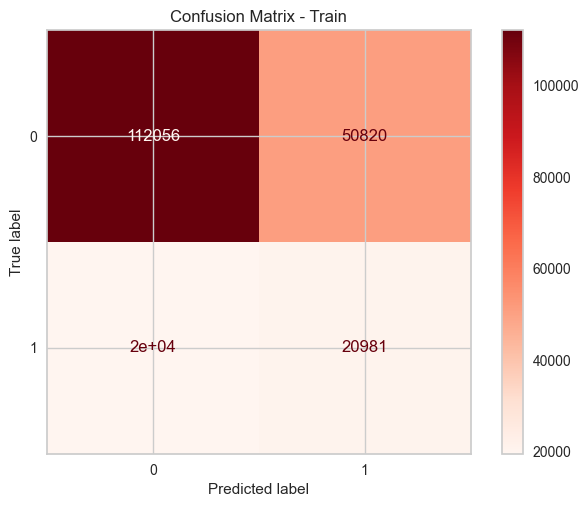

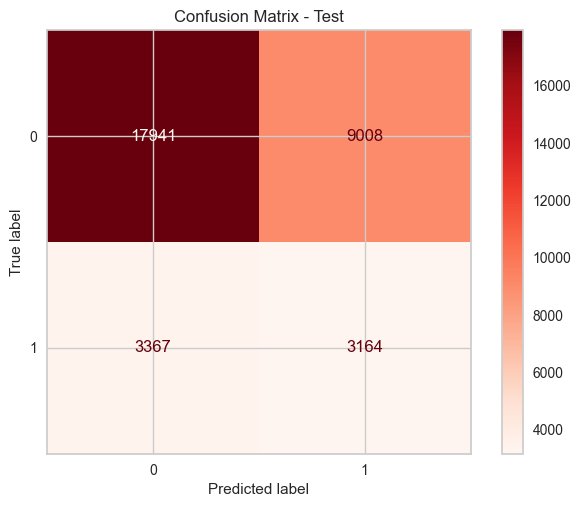

In [23]:
# Checking The Best Model Performance
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print('--- Classification Report: Train ---')
print(classification_report(y_train, y_pred_train))
print()

print('--- Classification Report: Test ---')
print(classification_report(y_test, y_pred_test))
print()

print('--- Confusion Matrix ---')
disp_train = ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, cmap='Reds')
disp_train.ax_.set_title('Confusion Matrix - Train')
plt.show()

disp_test = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Reds')
disp_test.ax_.set_title('Confusion Matrix - Test')
plt.show()

# 9. Model Saving

In [25]:
# Saving Model
with open('C:/Users/DELL/Portfolio/Stock Pipeline/dags/ml_models/final_model.pkl', 'wb') as a:
    dill.dump(model, a)